 ## Model Improvement, Error Analysis & Validation

In [29]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve)
import statsmodels.api as sm
import warnings

In [30]:
#importing dataset
df = pd.read_csv('Downloads/HealthConnect_Appointment_Data.csv')

## Transition from Week 5 to Week 6


**Main Week 5 output:** A baseline Logistic Regression and Random Forest classifier predicting appointment no-shows, using features engineered from the cleaned dataset (`is_new_patient`, `prior_no_show_rate`, `lead_time_bucket`).

**Most important result:** Logistic Regression outperformed Random Forest on every metric (ROC-AUC 0.669 vs. 0.635), suggesting the relationship between features and no-show risk is largely linear/additive.

**Main limitation:** Overall performance was modest (AUC 0.65–0.67 range). The model captures real signal but is far from a strong predictor. Week 5 did not investigate **where** the model was wrong, only that it was imperfect in aggregate.

**Relevant track this week:** Data Analytics track.  Their segment-level view of no-show behaviour (by lead time and reminder status) can surface interaction effects that individual features didn't capture in Week 5.

**Week 6 intent:** Conduct error analysis on the Week 5 baseline, incorporate a real cross-track analytical finding into a refined feature, develop and compare an improved model, and validate whether performance is adequate for the actual use case.

## Week 6 Integration Readiness


**A. Integration point**

- **Track working with:** Data Analytics
- **Output needed from that track:** Validated descriptive findings on which appointment/patient factors relate to no-show behaviour, to check whether the Week 5 feature set was well-justified or contained redundant/weak features
- **Output provided to that track:** Evidence-based answers on feature validity (ablation results, statistical significance, and a previously undetected collinearity issue), which the analyst can use to refine their own reporting
- **Why relevant:** Data Analytics' independent descriptive analysis is the natural check on whether Data Science's engineered features actually reflect real patterns in the data, rather than assumptions carried over from Week 4

**B. Integration objective (stated before the work below)**
After this integration activity, the Week 5 feature set should be reduced to only features that are either statistically justified or demonstrably non-redundant. Any weak or collinear features identified and removed, backed by evidence rather than judgement calls alone.

**C. Evidence this activity will produce**
- Updated/refined dataset export (`HealthConnect_Cleaned_Modelling_Data_Week6.csv`)
- Ablation study (ROC-AUC comparisons)
- Statistical significance table
- A refined model built on the resulting feature set, compared against the Week 5 baseline

## Cross-Track Integration

**Real Data Analytics Findings**

The following findings were shared directly by a Data Analytics track intern (Audrey Mphisa) working independently on the same HealthConnect dataset:

1. **Booking lead time** has the strongest observed relationship with no-shows — rising from 27.81% (0–7 days) to 67.69% (46–60 days).
2. **Previous no-show history** matters — 55.41% no-show rate with ≥1 prior no-show vs. 43.51% with none.
3. **Reminder status** shows a modest difference — 47.36% (reminder sent) vs. 51.39% (not sent) — flagged by the analyst as an association, not necessarily causal.
4. **Distance** shows an access-related pattern — 46.45% (0–5km) vs. 57.76% (20+km).
5. **Waiting time** does not differentiate outcomes — 24.29 min (attended) vs. 24.20 min (no-show).

The analyst also asked six direct questions about the Week 5/6 feature set, which this notebook answers with evidence below.

Does:
1. `lead_time_bucket` adds value beyond booking_lead_days?
2. `prior_no_show_rate` adds value beyond previous_no_shows?
3. `is_new_patient` adds value beyond previous_appointments?
4. `reminder_sent`/`reminder_channel` materially improve prediction?
5. distance remains an important feature after the other variables are considered and
6. which features are most important in the Logistic Regression baseline.

## Rebuilding the Week 5 Feature Set (for the ablation study)

In [31]:
df_model = df[df['appointment_outcome'] != 'Cancelled'].copy()
df_model['target'] = (df_model['appointment_outcome'] == 'No-Show').astype(int)
df_model['reminder_channel'] = df_model['reminder_channel'].fillna('Not Sent')
df_model['distance_to_clinic_km'] = df_model['distance_to_clinic_km'].fillna(df_model['distance_to_clinic_km'].median())

overall_rate = df_model['previous_no_shows'].sum() / df_model.loc[df_model['previous_appointments']>0,'previous_appointments'].sum()
df_model['is_new_patient'] = (df_model['previous_appointments']==0).astype(int)
df_model['prior_no_show_rate'] = np.where(df_model['previous_appointments']>0, df_model['previous_no_shows']/df_model['previous_appointments'], overall_rate)
df_model['lead_time_bucket'] = pd.cut(df_model['booking_lead_days'], bins=[-1,15,45,100], labels=['Short','Medium','Long'])

print("Feature set rebuilt:", df_model.shape)

Feature set rebuilt: (4737, 22)


### Answering the questions (Ablation Study)

Each question is tested by comparing model AUC with vs. without the feature in question, rather than relying on intuition.

In [32]:
# writing a function to handle this 

base_cols = ['age','gender','appointment_type','booking_lead_days','previous_appointments',
             'previous_no_shows','reminder_sent','reminder_channel','distance_to_clinic_km',
             'appointment_day','appointment_time','is_new_patient','prior_no_show_rate','lead_time_bucket']

def build_and_eval(cols, label):
    cat_cols = [c for c in ['gender','appointment_type','appointment_day','appointment_time','reminder_sent','reminder_channel','lead_time_bucket'] if c in cols]
    sub = df_model[cols + ['target']].copy()
    enc = pd.get_dummies(sub, columns=cat_cols, drop_first=True)
    X = enc.drop(columns=['target']); y = enc['target']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    num_present = [c for c in ['age','booking_lead_days','previous_appointments','previous_no_shows','distance_to_clinic_km','prior_no_show_rate'] if c in X.columns]
    scaler = StandardScaler()
    X_train_s, X_test_s = X_train.copy(), X_test.copy()
    if num_present:
        X_train_s[num_present] = scaler.fit_transform(X_train[num_present])
        X_test_s[num_present] = scaler.transform(X_test[num_present])
    lr = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_s, y_train)
    proba = lr.predict_proba(X_test_s)[:,1]
    auc = roc_auc_score(y_test, proba)
    print(f"{label}: AUC = {auc:.4f}  (n_features={X.shape[1]})")
    return auc

full_auc = build_and_eval(base_cols, "Full model (all Week 5 features)")

Full model (all Week 5 features): AUC = 0.6690  (n_features=26)


In [33]:
print("\n--- Q1: lead_time_bucket vs booking_lead_days ---")
build_and_eval([c for c in base_cols if c != 'lead_time_bucket'], "Without lead_time_bucket")
build_and_eval([c for c in base_cols if c != 'booking_lead_days'], "Without booking_lead_days")


--- Q1: lead_time_bucket vs booking_lead_days ---
Without lead_time_bucket: AUC = 0.6682  (n_features=24)
Without booking_lead_days: AUC = 0.6620  (n_features=25)


0.6620204404266214

**Interpretation** : Dropping `lead_time_bucket` barely changes AUC (0.6690 → 0.6682); dropping `booking_lead_days` hurts more (→ 0.6620). The continuous variable does all the work essentially — `lead_time_bucket` is redundant.

In [34]:
print("--- Q2: prior_no_show_rate vs previous_no_shows ---")
build_and_eval([c for c in base_cols if c != 'prior_no_show_rate'], "Without prior_no_show_rate")
build_and_eval([c for c in base_cols if c != 'previous_no_shows'], "Without previous_no_shows")

--- Q2: prior_no_show_rate vs previous_no_shows ---
Without prior_no_show_rate: AUC = 0.6669  (n_features=25)
Without previous_no_shows: AUC = 0.6637  (n_features=25)


0.6636547839059472

**Interpretation**: Both matter somewhat since dropping either lowers the AUC, but `previous_no_shows` (the raw count) carries more weight than the engineered rate. So the decision is to keep both

In [35]:
print("--- Q3: is_new_patient vs previous_appointments ---")
build_and_eval([c for c in base_cols if c != 'is_new_patient'], "Without is_new_patient")
build_and_eval([c for c in base_cols if c != 'previous_appointments'], "Without previous_appointments")

--- Q3: is_new_patient vs previous_appointments ---
Without is_new_patient: AUC = 0.6685  (n_features=25)
Without previous_appointments: AUC = 0.6681  (n_features=25)


0.6681035826412238

**Interpretation**: Dropping either changes AUC by <0.001. This is expected, since `is_new_patient` is definitionally `previous_appointments` == 0. This makes `is_new_patient`redundant.

In [36]:
print("--- Q4: reminder_sent / reminder_channel ---")
build_and_eval([c for c in base_cols if c not in ['reminder_sent','reminder_channel']], "Without both reminder fields")

print("\n--- Checking for collinearity between reminder_sent and reminder_channel ---")
print(pd.crosstab(df_model['reminder_sent'], df_model['reminder_channel']))

--- Q4: reminder_sent / reminder_channel ---
Without both reminder fields: AUC = 0.6693  (n_features=22)

--- Checking for collinearity between reminder_sent and reminder_channel ---
reminder_channel  Email  Not Sent   SMS  WhatsApp
reminder_sent                                    
No                    0      1285     0         0
Yes                 506         0  1907      1039


**Interpretation**: The two reminder variables contain the same information: “Not Sent” always means no reminder was sent, while every other channel means a reminder was sent. Including both variables creates perfect overlap, making `reminder_sent` impossible to interpret reliably. Since `reminder_channel` provides more detail and removing both barely changed the AUC, we will drop `reminder_sent` and keep `reminder_channel`.

In [37]:
print("--- Q5: distance_to_clinic_km ---")
build_and_eval([c for c in base_cols if c != 'distance_to_clinic_km'], "Without distance_to_clinic_km")

--- Q5: distance_to_clinic_km ---
Without distance_to_clinic_km: AUC = 0.6696  (n_features=25)


0.6696399545768297

**Interpretation**: Dropping distance slightly improved AUC (0.6690 - 0.6696). The bivariate difference (46.45% vs. 57.76%) is confirmed, but distance adds no independent predictive value after accounting for booking lead time and prior no-show history.

In [38]:
cat_cols = ['gender','appointment_type','appointment_day','appointment_time','reminder_sent','reminder_channel','lead_time_bucket']
sub = df_model[base_cols + ['target']].copy()
enc = pd.get_dummies(sub, columns=cat_cols, drop_first=True)
for c in enc.columns:
    if enc[c].dtype == bool:
        enc[c] = enc[c].astype(int)

X = enc.drop(columns=['target']).astype(float)
y = enc['target']
num_present = ['age','booking_lead_days','previous_appointments','previous_no_shows','distance_to_clinic_km','prior_no_show_rate']
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[num_present] = scaler.fit_transform(X[num_present])

X_sm = sm.add_constant(X_scaled)
logit_model = sm.Logit(y, X_sm).fit(disp=0)

sig_results = pd.DataFrame({'coef': logit_model.params, 'p_value': logit_model.pvalues}).drop('const')
sig_results['significant_at_0.05'] = sig_results['p_value'] < 0.05
print(sig_results.sort_values('p_value').round(4))

                                            coef  p_value  significant_at_0.05
booking_lead_days                         0.5187   0.0000                 True
previous_no_shows                         0.4156   0.0000                 True
distance_to_clinic_km                     0.1499   0.0000                 True
prior_no_show_rate                       -0.1351   0.0257                 True
previous_appointments                    -0.0978   0.0294                 True
appointment_day_Wednesday                 0.2279   0.0461                 True
appointment_day_Monday                    0.2235   0.0531                False
gender_Prefer not to say                 -0.3807   0.0771                False
age                                      -0.0527   0.0879                False
appointment_day_Thursday                  0.1835   0.1147                False
appointment_day_Sunday                    0.1770   0.1181                False
lead_time_bucket_Long                     0.3308   0

C:\Users\hp\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


**Findings**: Six features are statistically significant at p < 0.05: `booking_lead_days`, `previous_no_shows`, `distance_to_the_clinic`, `prior_no_show_rate`, `previous_appointments`, and appointments scheduled on Wednesday.

Distance to the clinic is statistically significant in this model, even though the ablation study showed that removing it does not reduce AUC. This is not a contradiction because statistical significance and predictive discrimination measure different things. Both findings should therefore be reported.

The remaining variables, including the reminder and demographic fields, are not statistically significant. The p-value for reminder sent Yes is exactly 1.0000, providing further statistical evidence of the collinearity issue identified earlier.

## Error Analysis

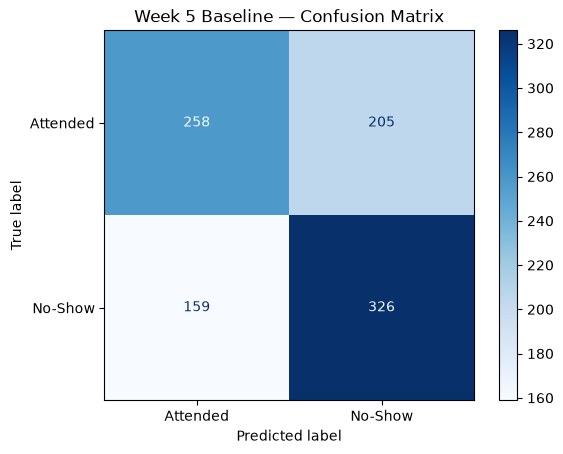

True Negatives (correctly predicted Attended): 258
False Positives (predicted No-Show, actually Attended): 205
False Negatives (predicted Attended, actually No-Show): 159
True Positives (correctly predicted No-Show): 326


In [39]:
cm = confusion_matrix(y_test_b, baseline_pred)
ConfusionMatrixDisplay(cm, display_labels=['Attended','No-Show']).plot(cmap='Blues')
plt.title('Week 5 Baseline — Confusion Matrix')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly predicted Attended): {tn}")
print(f"False Positives (predicted No-Show, actually Attended): {fp}")
print(f"False Negatives (predicted Attended, actually No-Show): {fn}")
print(f"True Positives (correctly predicted No-Show): {tp}")

**Interpretation:** False negatives are the more important error here. If the model predicts a patient will attend but they actually no-show, HealthConnect misses the chance to intervene, which is more costly than a false positive, where the patient comes anyway and only an extra reminder call is wasted. That’s why recall for the No-Show class is the more meaningful measure than overall accuracy here.

In [40]:
# Comparing false negatives and true positives
error_df = X_test_b.copy()
error_df['actual'] = y_test_b.values
error_df['predicted'] = baseline_pred

false_negatives = error_df[(error_df['actual']==1) & (error_df['predicted']==0)]
true_positives = error_df[(error_df['actual']==1) & (error_df['predicted']==1)]

print("False Negatives — mean feature values:")
print(false_negatives[['prior_no_show_rate','booking_lead_days','previous_no_shows']].mean().round(3))
print()
print("True Positives — mean feature values:")
print(true_positives[['prior_no_show_rate','booking_lead_days','previous_no_shows']].mean().round(3))

False Negatives — mean feature values:
prior_no_show_rate     0.131
booking_lead_days     18.075
previous_no_shows      0.403
dtype: float64

True Positives — mean feature values:
prior_no_show_rate     0.213
booking_lead_days     43.782
previous_no_shows      0.718
dtype: float64


In [42]:
# saving the feature engineered datasets
df_model.to_csv('HealthConnect_Cleaned_Modelling_Data_Week6.csv', index=False)
print("Saved: HealthConnect_Cleaned_Modelling_Data_Week6.csv")
print("Shape:", df_model.shape)

Saved: HealthConnect_Cleaned_Modelling_Data_Week6.csv
Shape: (4737, 22)


### Refined Model 

Based on the ablation study and significance testing, the refined feature set:
- **Drops:** `lead_time_bucket` (redundant with `booking_lead_days`), `is_new_patient` (redundant with `previous_appointments`), `reminder_sent` (collinear with `reminder_channel`)
- **Keeps:** Keeping  everything else, including `distance_to_clinic_km` (individually significant, even though it doesn't help AUC) and `reminder_channel` (in place of the collinear `reminder_sent`)

In [44]:
refined_cols = ['age','gender','appointment_type','booking_lead_days','previous_appointments',
                'previous_no_shows','reminder_channel','distance_to_clinic_km',
                'appointment_day','appointment_time','prior_no_show_rate']

cat_refined = ['gender','appointment_type','appointment_day','appointment_time','reminder_channel']
sub_refined = df_model[refined_cols + ['target']].copy()
enc_refined = pd.get_dummies(sub_refined, columns=cat_refined, drop_first=True)

X_r = enc_refined.drop(columns=['target']); y_r = enc_refined['target']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_r, y_r, test_size=0.2, random_state=42, stratify=y_r)

num_refined = ['age','booking_lead_days','previous_appointments','previous_no_shows','distance_to_clinic_km','prior_no_show_rate']
scaler_r = StandardScaler()
X_train_rs, X_test_rs = X_train_r.copy(), X_test_r.copy()
X_train_rs[num_refined] = scaler_r.fit_transform(X_train_r[num_refined])
X_test_rs[num_refined] = scaler_r.transform(X_test_r[num_refined])

lr_refined = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_rs, y_train_r)
gb_refined = GradientBoostingClassifier(random_state=42).fit(X_train_r, y_train_r)

pred_lr_r = lr_refined.predict(X_test_rs); proba_lr_r = lr_refined.predict_proba(X_test_rs)[:,1]
pred_gb_r = gb_refined.predict(X_test_r); proba_gb_r = gb_refined.predict_proba(X_test_r)[:,1]

print("Refined models trained on the leaner, evidence-justified feature set.")

Refined models trained on the leaner, evidence-justified feature set.


In [45]:
def evaluate(name, y_true, y_pred, y_proba):
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.3f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.3f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.3f}")
    print()

print("=== WEEK 5 BASELINE (all original features) ===")
evaluate("Logistic Regression (baseline)", y_test_b, baseline_pred, baseline_proba)

print("=== WEEK 6 REFINED (evidence-based leaner feature set) ===")
evaluate("Logistic Regression (refined)", y_test_r, pred_lr_r, proba_lr_r)
evaluate("Gradient Boosting (refined)", y_test_r, pred_gb_r, proba_gb_r)

=== WEEK 5 BASELINE (all original features) ===
--- Logistic Regression (baseline) ---
Accuracy:  0.616
Precision: 0.614
Recall:    0.672
F1-score:  0.642
ROC-AUC:   0.669

=== WEEK 6 REFINED (evidence-based leaner feature set) ===
--- Logistic Regression (refined) ---
Accuracy:  0.615
Precision: 0.613
Recall:    0.672
F1-score:  0.641
ROC-AUC:   0.668

--- Gradient Boosting (refined) ---
Accuracy:  0.617
Precision: 0.617
Recall:    0.662
F1-score:  0.639
ROC-AUC:   0.661



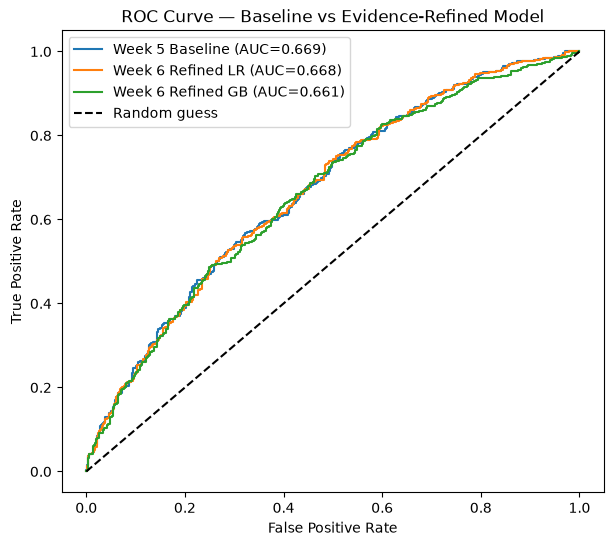

In [51]:
# Plotting ROC curve showing baseline vs refined model
fig, ax = plt.subplots(figsize=(7,6))
for name, y_true, proba in [
    ('Week 5 Baseline', y_test_b, baseline_proba),
    ('Week 6 Refined LR', y_test_r, proba_lr_r),
    ('Week 6 Refined GB', y_test_r, proba_gb_r),
]:
    fpr, tpr, _ = roc_curve(y_true, proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_true, proba):.3f})")
ax.plot([0,1],[0,1],'k--', label='Random guess')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Baseline vs Evidence-Refined Model')
ax.legend()
plt.show()

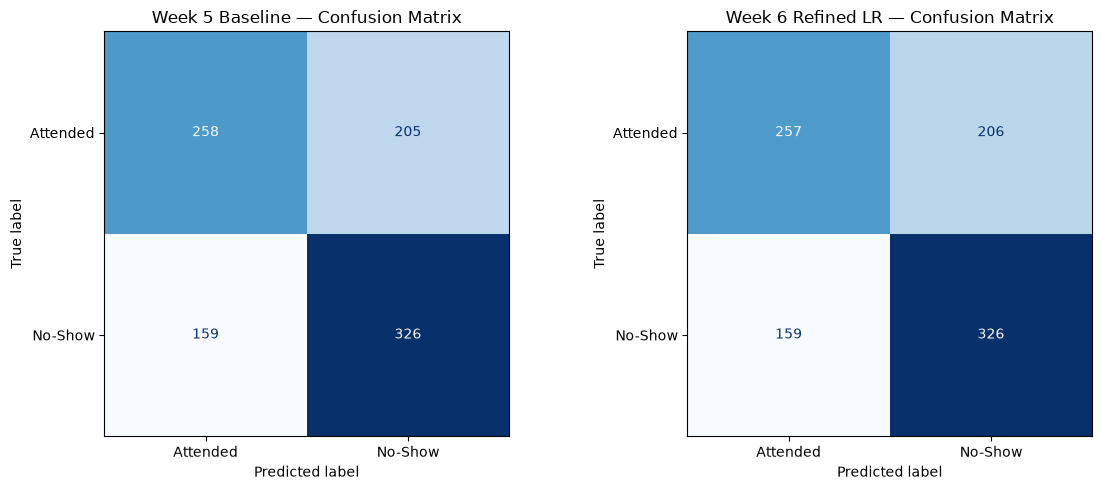

In [50]:
# Confusion matrix comparing baseline vs. refined logistic regression
fig, axes = plt.subplots(1, 2, figsize=(12,5))
ConfusionMatrixDisplay(confusion_matrix(y_test_b, baseline_pred), display_labels=['Attended','No-Show']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Week 5 Baseline — Confusion Matrix')
ConfusionMatrixDisplay(confusion_matrix(y_test_r, pred_lr_r), display_labels=['Attended','No-Show']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Week 6 Refined LR — Confusion Matrix')
plt.tight_layout()
plt.show()

## Part 6: Business Relevance, Suitability Assessment & Candidate Model Recommendation

### Real results (from Part 5, executed above)

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Week 5 Baseline (Logistic Regression) | 0.616 | 0.614 | 0.672 | 0.642 | 0.669 |
| Week 6 Refined Logistic Regression | 0.615 | 0.613 | 0.672 | 0.641 | 0.668 |
| Week 6 Refined Gradient Boosting | 0.617 | 0.617 | 0.662 | 0.639 | 0.661 |

### Business Relevance

For HealthConnect, a false negative occurs when the model predicts that a patient will attend, but the patient does not. This is more costly than a false positive. A false negative leaves an appointment slot unused, with no opportunity for intervention, whereas a false positive only results in an additional reminder call. Therefore, recall for the no-show class is more important for practical use than accuracy alone.

The refined logistic regression matches the baseline recall of 0.672. Gradient boosting has a lower recall of 0.662 despite slightly higher accuracy and precision. Because HealthConnect’s priority is to identify as many likely no-shows as possible, the refined logistic regression is better aligned with the business objective.

### Candidate Model Recommendation

The Week 6 refined logistic regression is recommended as the candidate model for Week 7. Its ROC AUC of 0.668 is nearly identical to the Week 5 baseline value of 0.669, a difference of only 0.001. However, it uses a leaner feature set supported by the analysis and resolves the redundancy and collinearity issues identified this week. This makes it simpler to maintain without sacrificing meaningful predictive performance.

Gradient boosting is not recommended at this stage. Its recall is lower, which conflicts with HealthConnect’s priority of identifying no-shows, and its additional complexity is not supported by a meaningful performance improvement.

### Suitability Assessment

With a ROC AUC of approximately 0.67, the model captures meaningful predictive signal but is not strong enough to automate intervention decisions fully. It should not be used to cancel appointments or reallocate slots without human review.

The model is suitable as a risk flagging tool that identifies higher risk appointments for staff follow up, such as an additional reminder call. It is not yet suitable as a fully autonomous decision system. This limitation should be communicated clearly to HealthConnect stakeholders so that the model’s current level of maturity is understood.

## Assumptions, Limitations, Risks & Dependencies (Weeks 4–6 Review)

**Resolved since Week 5:**
- `waiting_time_minutes` leakage risk, flagged in Week 4 and excluded in Week 5, remains correctly excluded.
- Uncertainty about the Week 5 feature set was resolved through this week’s ablation study. `lead_time_bucket`, `is_new_patient`, and `reminder_sent` were confirmed as redundant or collinear and removed.

**Remaining/unresolved:**
- Overall predictive power remains modest, with an ROC AUC of approximately 0.67, even after feature refinement. This appears to reflect a limitation of the current feature set and dataset rather than an issue that feature selection alone can solve.
- The model still struggles most with no-shows from patients without a prior risk history, as shown in the Part 4 error analysis. This issue was not resolved by this week’s changes.

**Issues discovered this week:**
- Perfect collinearity was identified between `reminder_sent` and `reminder_channel`, which had not been detected in Week 5.
- `distance_to_clinic_km` is statistically significant on its own but does not meaningfully improve overall model discrimination. This distinction had not been documented previously.

**New cross-track dependency:**
- Continued coordination with the Data Analytics intern is needed to confirm that the refined feature list reflects their findings and to agree on how features such as distance, which are statistically significant but contribute little to AUC, should be reported to stakeholders.

**Technical/modelling limitations:**
- Cross-validation has not yet been performed, so the results from the single train-test split should be treated as indicative.
- A full VIF audit has not been completed across the refined feature set. Only the identified collinearity pair was investigated in response to the analyst’s specific question.

**Potential impact on the project:** If the AUC ceiling of approximately 0.67 does not improve with richer features in Week 7, HealthConnect should be advised to treat the model as a risk flagging aid rather than an autonomous system. This may affect pipeline design decisions in the ML Engineering track.

**Recommended mitigation:** Conduct cross-validation and a full VIF audit in Week 7, as outlined in the Week 7 Testing Requirements. Continue coordinating with Data Analytics on new segment-level findings that could inform additional features.